In [1]:
# Visualization
import matplotlib.pyplot as plt

# Data handling
import pandas as pd
import numpy as np

# Image processing
from PIL import Image
import os

# Label encoding
from sklearn.preprocessing import LabelEncoder

# Deep learning
import tensorflow as tf
from tensorflow import keras

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Jupyter inline plotting
%matplotlib inline

Image Label: automobile


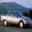

In [2]:
# Load labels CSV
labels = pd.read_csv('dataset/cifar10Labels.csv')

# Select image index
img_idx = 5

# Get label
img_label = labels.loc[img_idx, 'label']

print("Image Label:", img_label)

# Build image path
img_path = os.path.join('dataset', 'cifar10', f'{img_idx}.png')

# Open and display image
img = Image.open(img_path)
display(img)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Split labels into train and test
train_df, test_df = train_test_split(
    labels,
    test_size=0.3,
    random_state=42,
    stratify=labels['label']
)

# Store indexes for later use
train_idx = train_df.index
test_idx = test_df.index

# Function to load images
def load_images(dataframe, image_folder):
    images = []

    for img_idx in dataframe.index:
        img_path = os.path.join(image_folder, f"{img_idx}.png")

        img = Image.open(img_path)
        img = np.array(img, dtype='float32')

        images.append(img)

    return np.array(images)

# Load images
X_train = load_images(train_df, 'dataset/cifar10')
X_test = load_images(test_df, 'dataset/cifar10')

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Encode labels
encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df['label'])
y_test = encoder.transform(test_df['label'])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (35000, 32, 32, 3)
X_test shape: (15001, 32, 32, 3)
y_train shape: (35000,)
y_test shape: (15001,)


In [4]:
from tensorflow import keras
from tensorflow.keras import layers

num_classes = 10

model = keras.Sequential([
    
    # Input layer
    layers.Input(shape=(32, 32, 3)),

    # Block 1
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding='same',
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(0.001),
        name='Conv_1'
    ),
    layers.BatchNormalization(name='BN_1'),
    layers.MaxPooling2D(pool_size=(2, 2), name='MaxPool_1'),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding='same',
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(0.001),
        name='Conv_2'
    ),
    layers.BatchNormalization(name='BN_2'),
    layers.MaxPooling2D(pool_size=(2, 2), name='MaxPool_2'),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        padding='same',
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(0.001),
        name='Conv_3'
    ),
    layers.BatchNormalization(name='BN_3'),
    layers.MaxPooling2D(pool_size=(2, 2), name='MaxPool_3'),
    layers.Dropout(0.3),

    # Flatten
    layers.Flatten(name='Flatten'),

    # Dense classifier
    layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(0.001),
        name='Dense_1'
    ),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(
        num_classes,
        activation='softmax',
        name='Output'
    )
])

# Model summary
model.summary()

2026-05-17 14:34:01.195831: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-17 14:34:01.195919: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-17 14:34:01.195928: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1779008641.195963  114242 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1779008641.196180  114242 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv_1 (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_1 (BatchNormalization)       │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_2 (BatchNormalization)       │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_3 (BatchNormalization)       │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_3 (MaxPooling2D)        │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [5]:
from tensorflow import keras

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='best_cifar10_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Training
epochs = 30
batch_size = 64

history = model.fit(
    X_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=[checkpoint, early_stopping, reduce_lr],
    verbose=1,
    shuffle=True
)

Epoch 1/30


2026-05-17 14:34:02.541666: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2327 - loss: 9.1179
Epoch 1: val_accuracy improved from None to 0.26171, saving model to best_cifar10_model.keras

Epoch 1: finished saving model to best_cifar10_model.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.2759 - loss: 7.8715 - val_accuracy: 0.2617 - val_loss: 3.6901 - learning_rate: 0.0010
Epoch 2/30
437/438 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3634 - loss: 4.0682
Epoch 2: val_accuracy improved from 0.26171 to 0.46414, saving model to best_cifar10_model.keras

Epoch 2: finished saving model to best_cifar10_model.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.3824 - loss: 3.2877 - val_accuracy: 0.4641 - val_loss: 1.9766 - learning_rate: 0.0010
Epoch 3/30
437/438 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4576 - loss: 1.9970
Epoch 3: val_accuracy improved from 0.46414 to 0.49500, saving model to best_cifar10_model.keras

Epoch 3: finished saving model to best_cifar10_model.ke

In [6]:
# Predict first 10 test images
pred_probs = model.predict(X_test[50:60], verbose=0)

# Convert probability vectors to class indices
pred_indices = np.argmax(pred_probs, axis=1)

# Convert numeric labels back to class names
pred_labels = encoder.inverse_transform(pred_indices)
actual_labels = encoder.inverse_transform(y_test[50:60])

# Create comparison dataframe
results = pd.DataFrame({
    'Predicted': pred_labels,
    'Actual': actual_labels
})

results

,Predicted,Actual
0,frog,frog
1,automobile,ship
2,horse,horse
3,frog,frog
4,bird,bird
5,ship,ship
6,bird,bird
7,automobile,automobile
8,airplane,airplane
9,truck,truck


In [7]:
from sklearn.metrics import accuracy_score

# Predict class probabilities
train_pred_probs = model.predict(X_train, verbose=0)
test_pred_probs = model.predict(X_test, verbose=0)

# Convert probabilities to class indices
train_pred = np.argmax(train_pred_probs, axis=1)
test_pred = np.argmax(test_pred_probs, axis=1)

# Calculate accuracy
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", round(train_acc, 5))
print("Test Accuracy:", round(test_acc, 5))

Train Accuracy: 0.8694
Test Accuracy: 0.79381


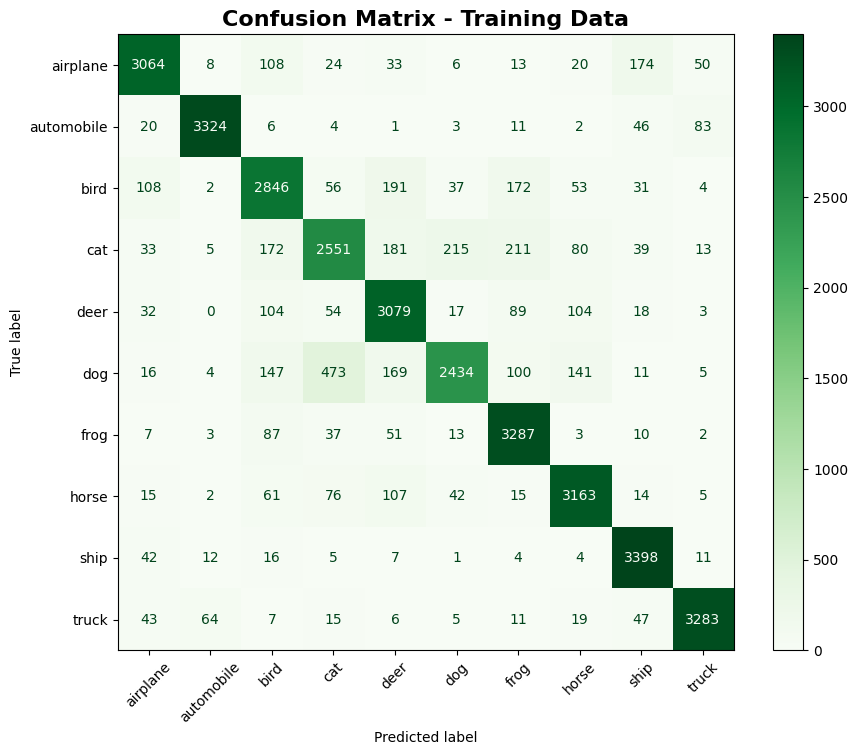

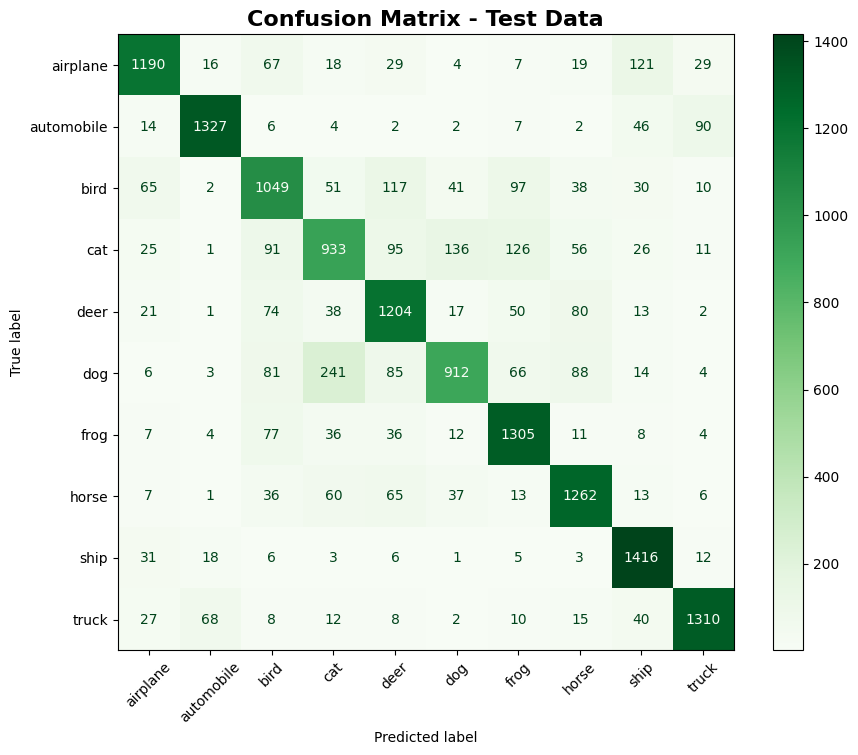

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Class names
class_names = encoder.classes_

# Predictions
train_pred = np.argmax(model.predict(X_train, verbose=0), axis=1)
test_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

# Confusion matrices
train_cm = confusion_matrix(y_train, train_pred)
test_cm = confusion_matrix(y_test, test_pred)

# Plot function
def plot_cm(cm, title):
    plt.figure(figsize=(10, 8))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        cmap='Greens',
        values_format='d',
        ax=plt.gca(),
        colorbar=True
    )

    plt.xticks(rotation=45)
    plt.title(title, fontsize=16, fontweight='bold')
    plt.show()

# Plot
plot_cm(train_cm, "Confusion Matrix - Training Data")
plot_cm(test_cm, "Confusion Matrix - Test Data")

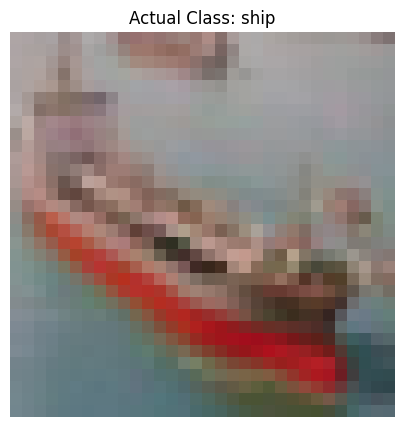

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Class names
classes = encoder.classes_

# Select a test image
sample_idx = 6
image_id = test_idx[sample_idx]

# Build path
img_path = os.path.join('dataset', 'cifar10', f'{image_id}.png')

# Load image
img = Image.open(img_path)

# Display
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Actual Class: {classes[y_test[sample_idx]]}")
plt.axis('off')
plt.show()

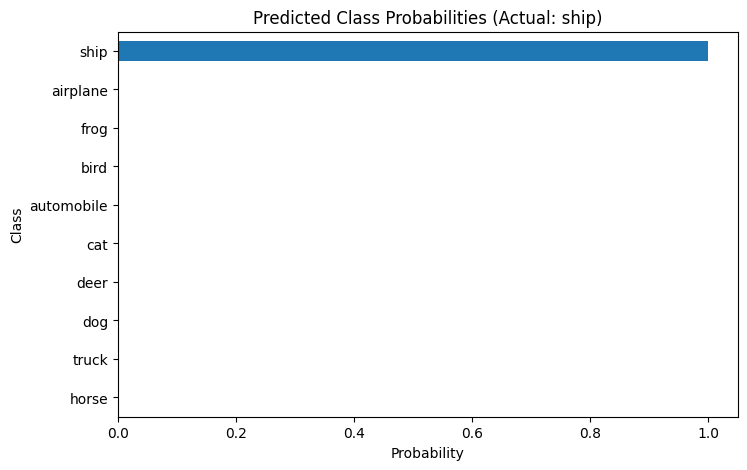

In [10]:
# Select test sample
sample_idx = 6

# Predict probabilities
pred_probs = model.predict(X_test[sample_idx:sample_idx+1], verbose=0)

# Convert to 1D array
pred_probs = pred_probs.flatten()

# Create dataframe/series
prob_series = pd.Series(pred_probs, index=encoder.classes_)

# Plot
plt.figure(figsize=(8, 5))
prob_series.sort_values().plot(kind='barh')

plt.title(f'Predicted Class Probabilities (Actual: {encoder.classes_[y_test[sample_idx]]})')
plt.xlabel('Probability')
plt.ylabel('Class')
plt.show()

In [11]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score
import numpy as np

def build_cnn_model(stride=1, kernel_size=(3, 3)):
    model = keras.Sequential([
        
        layers.Input(shape=(32, 32, 3)),

        # First Conv Block
        layers.Conv2D(
            filters=32,
            kernel_size=kernel_size,
            strides=stride,
            padding='same',
            activation='relu',
            kernel_regularizer=keras.regularizers.l2(0.001),
            name='Conv_1'
        ),
        layers.BatchNormalization(name='BN_1'),
        layers.MaxPooling2D(pool_size=(2, 2), name='MaxPool_1'),
        layers.Dropout(0.25),

        # Second Conv Block
        layers.Conv2D(
            filters=64,
            kernel_size=kernel_size,
            strides=stride,
            padding='same',
            activation='relu',
            kernel_regularizer=keras.regularizers.l2(0.001),
            name='Conv_2'
        ),
        layers.BatchNormalization(name='BN_2'),
        layers.MaxPooling2D(pool_size=(2, 2), name='MaxPool_2'),
        layers.Dropout(0.25),

        # Flatten
        layers.Flatten(),

        # Output
        layers.Dense(10, activation='softmax')
    ])

    return model


# Build model for Case 1
model_stride2 = build_cnn_model(stride=2, kernel_size=(3, 3))

# Compile
model_stride2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_stride2 = model_stride2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Predictions
train_pred = np.argmax(model_stride2.predict(X_train, verbose=0), axis=1)
test_pred = np.argmax(model_stride2.predict(X_test, verbose=0), axis=1)

# Accuracy
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", round(train_acc * 100, 2), "%")
print("Test Accuracy:", round(test_acc * 100, 2), "%")

Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.3121 - loss: 2.1535 - val_accuracy: 0.3430 - val_loss: 1.8193
Epoch 2/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4364 - loss: 1.6347 - val_accuracy: 0.4937 - val_loss: 1.4908
Epoch 3/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4879 - loss: 1.4782 - val_accuracy: 0.5250 - val_loss: 1.3900
Epoch 4/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5156 - loss: 1.4020 - val_accuracy: 0.5350 - val_loss: 1.3493
Epoch 5/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5417 - loss: 1.3506 - val_accuracy: 0.4750 - val_loss: 1.4952
Epoch 6/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5463 - loss: 1.3205 - val_accuracy: 0.4927 - val_loss: 1.4516
Epoch 7/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5577 - loss: 1.2946 - val_accuracy: 0.5533 - val_loss: 1.2950
Epoch 8/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5689 - loss: 1.2646 - val_accu

In [ ]:
# Case 2: Stride = 3, Filter = (3x3)

model_stride3 = build_cnn_model(
    stride=3,
    kernel_size=(3, 3)
)

# Compile
model_stride3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_stride3 = model_stride3.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Predictions
train_pred = np.argmax(
    model_stride3.predict(X_train, verbose=0),
    axis=1
)

test_pred = np.argmax(
    model_stride3.predict(X_test, verbose=0),
    axis=1
)

# Accuracy
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", round(train_acc * 100, 2), "%")
print("Test Accuracy:", round(test_acc * 100, 2), "%")

In [ ]:
# Case 3: Stride = 1, Filter = (2x2)

model_filter2 = build_cnn_model(
    stride=1,
    kernel_size=(2, 2)
)

# Compile
model_filter2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_filter2 = model_filter2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Predictions
train_pred = np.argmax(
    model_filter2.predict(X_train, verbose=0),
    axis=1
)

test_pred = np.argmax(
    model_filter2.predict(X_test, verbose=0),
    axis=1
)

# Accuracy
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", round(train_acc * 100, 2), "%")
print("Test Accuracy:", round(test_acc * 100, 2), "%")

Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4141 - loss: 2.0272 - val_accuracy: 0.4169 - val_loss: 1.6260
Epoch 2/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5179 - loss: 1.4877 - val_accuracy: 0.5630 - val_loss: 1.2996
Epoch 3/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5665 - loss: 1.3214 - val_accuracy: 0.5970 - val_loss: 1.1988
Epoch 4/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5961 - loss: 1.2127 - val_accuracy: 0.5077 - val_loss: 1.5398
Epoch 5/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6165 - loss: 1.1335 - val_accuracy: 0.6194 - val_loss: 1.1563
Epoch 6/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6342 - loss: 1.0813 - val_accuracy: 0.6084 - val_loss: 1.1568
Epoch 7/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6498 - loss: 1.0467 - val_accuracy: 0.6256 - val_loss: 1.1339
Epoch 8/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.6538 - loss: 1.0184 - val_accu

In [ ]:
# Case 4: Stride = 1, Filter = (4x4)

model_filter4 = build_cnn_model(
    stride=1,
    kernel_size=(4, 4)
)

# Compile
model_filter4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history_filter4 = model_filter4.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Predictions
train_pred = np.argmax(
    model_filter4.predict(X_train, verbose=0),
    axis=1
)

test_pred = np.argmax(
    model_filter4.predict(X_test, verbose=0),
    axis=1
)

# Accuracy
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", round(train_acc * 100, 2), "%")
print("Test Accuracy:", round(test_acc * 100, 2), "%")

Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.4063 - loss: 2.0097 - val_accuracy: 0.3600 - val_loss: 1.8664
Epoch 2/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.5238 - loss: 1.4963 - val_accuracy: 0.5780 - val_loss: 1.3048
Epoch 3/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.5816 - loss: 1.2950 - val_accuracy: 0.5637 - val_loss: 1.3463
Epoch 4/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.6177 - loss: 1.1603 - val_accuracy: 0.5331 - val_loss: 1.6306
Epoch 5/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6498 - loss: 1.0690 - val_accuracy: 0.6269 - val_loss: 1.1253
Epoch 6/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6675 - loss: 1.0123 - val_accuracy: 0.6100 - val_loss: 1.2395
Epoch 7/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6877 - loss: 0.9620 - val_accuracy: 0.6377 - val_loss: 1.1093
Epoch 8/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6948 - loss: 0.9368 - val_accu